In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tempfile import mkdtemp
from joblib import Memory

# Load the dataset
data = pd.read_csv('player_valuation_dataset.csv')
data.head()

,player_id,player_name,date_of_birth,height,citizenship,is_eu,position,main_position,foot,current_club_id,...,assists_per_90,goal_contributions,current_market_value,value_change_pct,total_days_injured,total_injuries,injury_proneness,competition_name,club_division,age
0,100001,Carlos Auzqui (100001),1991-03-16,180.0,Argentina,False,Attack - Right Winger,Attack,right,14554,...,0.44,79.0,200000.0,100.00,0.0,0.0,0.00,Torneo Clausura,Torneo Clausura,35
1,1000274,Brian Romero (1000274),2006-05-11,0.0,United States Mexico,False,Attack - Right Winger,Attack,NaN,78435,...,0.59,6.0,150000.0,0.00,0.0,0.0,0.00,Major League Soccer,Major League Soccer,19
2,1000273,Nimfasha Berchimas (1000273),2008-02-22,172.0,United States Burundi,False,Attack - Left Winger,Attack,right,78435,...,0.24,12.0,400000.0,-20.00,206.0,1.0,0.33,Major League Soccer,Major League Soccer,18
3,1000135,Joselu Pérez (1000135),2004-03-12,183.0,Spain,True,Attack - Centre-Forward,Attack,right,8510,...,0.00,8.0,100000.0,300.00,0.0,0.0,0.00,NaN,NaN,22
4,1000284,Jed Drew (1000284),2003-08-29,176.0,Australia,False,Attack - Right Winger,Attack,right,4467,...,0.75,39.0,550000.0,266.67,40.0,3.0,1.00,Bundesliga,Bundesliga,22


In [3]:
## Define X/y and clean data
TARGET = "current_market_value"

print(f"Initial data: {len(data)} rows")

# Check target column
print(f"Target column: {TARGET}")
print(f"Target missing: {data[TARGET].isna().sum()}")
print(f"Target infinite: {np.isinf(data[TARGET]).sum()}")

# 1. Drop rows where target is missing or invalid
data_clean = data[data[TARGET].notna() & np.isfinite(data[TARGET])].copy()
print(f"After target cleaning: {len(data_clean)} rows")

# 2. Engineer Date Features (NEW)
# Convert string dates to datetime objects
date_cols = ['joined', 'contract_expires']
for col in date_cols:
    data_clean[col] = pd.to_datetime(data_clean[col], errors='coerce')

# Calculate durations relative to the current date
current_date = pd.Timestamp('today')
data_clean['days_since_joined'] = (current_date - data_clean['joined']).dt.days
data_clean['days_until_contract_expires'] = (data_clean['contract_expires'] - current_date).dt.days

# 3. Drop Identifiers and Raw Dates (NEW)
# We remove raw dates and IDs to prevent the OneHotEncoder from crashing the model
columns_to_drop = [
    TARGET, 'player_id', 'player_name', 'index', 'current_club_id', 'club_id', 
    'date_of_birth', 'joined', 'contract_expires', 'date_of_death', 
    'date_of_last_contract_extension', 'current_club_name', 'on_loan_from_club_name', 
    'second_club_name', 'third_club_name', 'fourth_club_name', 'citizenship'
]
cols_to_drop_existing = [c for c in columns_to_drop if c in data_clean.columns]

# Replace inf/-inf with NaN in all numeric columns
numeric_cols = data_clean.select_dtypes(include=[np.number]).columns
data_clean[numeric_cols] = data_clean[numeric_cols].replace([np.inf, -np.inf], np.nan)

# 4. Fix Pandas Warnings (UPDATED: removed inplace=True)
# Fill NaN in numeric columns with median (skip target)
for col in numeric_cols:
    if col != TARGET and col in data_clean.columns:
        median_val = data_clean[col].median()
        if pd.isna(median_val):
            median_val = 0  # fallback if all values are NaN
        data_clean[col] = data_clean[col].fillna(median_val)

# Fill NaN in categorical columns with 'Unknown'
categorical_cols = data_clean.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    # Ensure we don't accidentally fill date columns if any slipped through
    if col not in date_cols: 
        data_clean[col] = data_clean[col].fillna('Unknown')

# Define Final X and y
X = data_clean.drop(columns=cols_to_drop_existing)
y = data_clean[TARGET]

# Identify feature types for the pipeline
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Initial data: 33557 rows
Target column: current_market_value
Target missing: 0
Target infinite: 0
After target cleaning: 33557 rows
Train size: (26845, 23)  Test size: (6712, 23)


In [4]:
# Helper to print metrics
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:20s}  RMSE: {rmse:,.0f}  MAE: {mae:,.0f}  R²: {r2:.4f}")
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

# ── 6. Baseline Linear Regression ──
lr_pipe = Pipeline([("pre", preprocess), ("model", LinearRegression())])
lr_pipe.fit(X_train, y_train)

results = []
results.append(evaluate("Linear Regression", y_test, lr_pipe.predict(X_test)))

Linear Regression     RMSE: 4,267,729  MAE: 1,473,231  R²: 0.4911


c:\Users\morga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [5]:
# 7. Regularized models: Ridge, Lasso, Elastic Net 
for name, model in [("Ridge", Ridge()), ("Lasso", Lasso()), ("ElasticNet", ElasticNet())]:
    pipe = Pipeline([("pre", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    results.append(evaluate(name, y_test, pipe.predict(X_test)))

c:\Users\morga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Ridge                 RMSE: 4,267,608  MAE: 1,472,635  R²: 0.4911


c:\Users\morga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.523e+17, tolerance: 1.026e+14
  model = cd_fast.sparse_enet_coordinate_descent(
c:\Users\morga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Lasso                 RMSE: 4,267,544  MAE: 1,472,895  R²: 0.4911
ElasticNet            RMSE: 4,742,901  MAE: 1,551,818  R²: 0.3714


c:\Users\morga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [6]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

# ── 8. Hyperparameter tuning via Specialized CV Estimators ──
X_train_pre = preprocess.fit_transform(X_train)
X_test_pre = preprocess.transform(X_test)

# 1. RidgeCV
ridge_cv = RidgeCV(
    alphas=[0.1, 1, 10], 
    cv=3, 
    scoring="neg_root_mean_squared_error"
)
ridge_cv.fit(X_train_pre, y_train)
print(f"Ridge best params: {{'alpha': {ridge_cv.alpha_}}}")
results.append(evaluate("Ridge (tuned)", y_test, ridge_cv.predict(X_test_pre)))

# 2. LassoCV
lasso_cv = LassoCV(
    alphas=[0.01, 0.1, 1], 
    cv=3, 
    n_jobs=-1, 
    max_iter=3000, 
    tol=1e-3, 
    selection="random"
)
lasso_cv.fit(X_train_pre, y_train)
print(f"Lasso best params: {{'alpha': {lasso_cv.alpha_}}}")
results.append(evaluate("Lasso (tuned)", y_test, lasso_cv.predict(X_test_pre)))

# 3. ElasticNetCV
enet_cv = ElasticNetCV(
    alphas=[0.01, 0.1, 1], 
    l1_ratio=[0.3, 0.7], 
    cv=3, 
    n_jobs=-1, 
    max_iter=3000, 
    tol=1e-3, 
    selection="random"
)
enet_cv.fit(X_train_pre, y_train)
print(f"ElasticNet best params: {{'alpha': {enet_cv.alpha_}, 'l1_ratio': {enet_cv.l1_ratio_}}}")
results.append(evaluate("ElasticNet (tuned)", y_test, enet_cv.predict(X_test_pre)))

print("\n── Summary ──")
print(pd.DataFrame(results).sort_values("RMSE"))

c:\Users\morga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Ridge best params: {'alpha': 10.0}
Ridge (tuned)         RMSE: 4,268,271  MAE: 1,471,749  R²: 0.4909


c:\Users\morga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.536e+17, tolerance: 6.527e+14
  model = cd_fast.sparse_enet_coordinate_descent(
c:\Users\morga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.757e+17, tolerance: 7.088e+14
  model = cd_fast.sparse_enet_coordinate_descent(
c:\Users\morga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations,

Lasso best params: {'alpha': 0.01}
Lasso (tuned)         RMSE: 4,267,544  MAE: 1,472,922  R²: 0.4911


c:\Users\morga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.278e+17, tolerance: 6.914e+14
  model = cd_fast.sparse_enet_coordinate_descent(
c:\Users\morga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.858e+16, tolerance: 6.527e+14
  model = cd_fast.sparse_enet_coordinate_descent(


ElasticNet best params: {'alpha': 0.01, 'l1_ratio': 0.7}
ElasticNet (tuned)    RMSE: 4,277,378  MAE: 1,472,791  R²: 0.4888

── Summary ──
                Model          RMSE           MAE        R2
5       Lasso (tuned)  4.267544e+06  1.472922e+06  0.491113
2               Lasso  4.267544e+06  1.472895e+06  0.491112
1               Ridge  4.267608e+06  1.472635e+06  0.491097
0   Linear Regression  4.267729e+06  1.473231e+06  0.491068
4       Ridge (tuned)  4.268271e+06  1.471749e+06  0.490939
6  ElasticNet (tuned)  4.277378e+06  1.472791e+06  0.488765
3          ElasticNet  4.742901e+06  1.551818e+06  0.371430


c:\Users\morga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.133e+17, tolerance: 1.026e+15
  model = cd_fast.sparse_enet_coordinate_descent(


# Next

- Advanced model RF, XGBOOST, Neural Network or SVM support vector machine
- Está a demorar bastante a correr. 

In [7]:
from sklearn.ensemble import RandomForestRegressor

print("Training Random Forest... (This might take 1-2 minutes)")

# Create the Random Forest pipeline
rf_pipe = Pipeline([
    ("pre", preprocess), 
    ("model", RandomForestRegressor(
        n_estimators=100,      # Number of trees
        max_depth=15,          # Limit depth to prevent overfitting
        random_state=42, 
        n_jobs=-1              # Use all CPU cores
    ))
])

# Train the model
rf_pipe.fit(X_train, y_train)

# Evaluate
print("\n── Random Forest Results ──")
results.append(evaluate("Random Forest", y_test, rf_pipe.predict(X_test)))

# Show updated summary
pd.DataFrame(results).sort_values("RMSE")

Training Random Forest... (This might take 1-2 minutes)

── Random Forest Results ──
Random Forest         RMSE: 3,696,438  MAE: 945,490  R²: 0.6182


c:\Users\morga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,RMSE,MAE,R2
7,Random Forest,3.696438e+06,9.454902e+05,0.618203
5,Lasso (tuned),4.267544e+06,1.472922e+06,0.491113
2,Lasso,4.267544e+06,1.472895e+06,0.491112
1,Ridge,4.267608e+06,1.472635e+06,0.491097
0,Linear Regression,4.267729e+06,1.473231e+06,0.491068
4,Ridge (tuned),4.268271e+06,1.471749e+06,0.490939
6,ElasticNet (tuned),4.277378e+06,1.472791e+06,0.488765
3,ElasticNet,4.742901e+06,1.551818e+06,0.371430


Tuning Random Forest and extracting Feature Importances... (ETA: 2-3 minutes)

Best Parameters Found: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__max_features': 1.0, 'model__max_depth': 25}
Random Forest (Tuned)  RMSE: 3,677,108  MAE: 920,485  R²: 0.6222

── Updated Summary ──
                   Model          RMSE           MAE        R2
8  Random Forest (Tuned)  3.677108e+06  9.204852e+05  0.622186
7          Random Forest  3.696438e+06  9.454902e+05  0.618203
5          Lasso (tuned)  4.267544e+06  1.472922e+06  0.491113
2                  Lasso  4.267544e+06  1.472895e+06  0.491112
1                  Ridge  4.267608e+06  1.472635e+06  0.491097
0      Linear Regression  4.267729e+06  1.473231e+06  0.491068
4          Ridge (tuned)  4.268271e+06  1.471749e+06  0.490939
6     ElasticNet (tuned)  4.277378e+06  1.472791e+06  0.488765
3             ElasticNet  4.742901e+06  1.551818e+06  0.371430


c:\Users\morga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


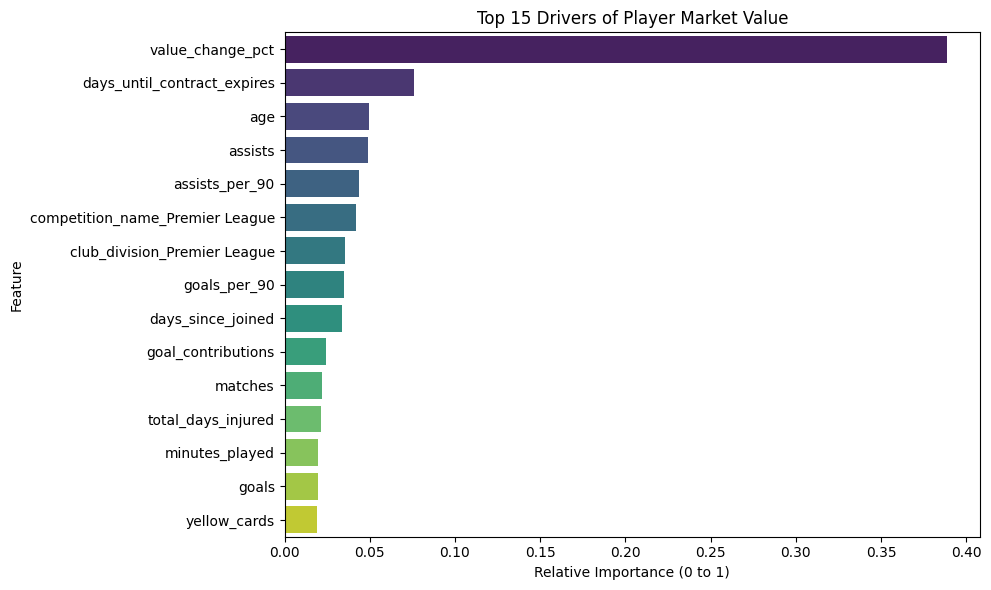

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV

print("Tuning Random Forest and extracting Feature Importances... (ETA: 2-3 minutes)")

# 1. Define the parameters we want to test
param_grid = {
    'model__n_estimators': [100, 200, 300],          # Number of trees
    'model__max_depth': [10, 15, 20, 25, None],      # How deep the trees can go
    'model__min_samples_split': [2, 5, 10],          # Minimum samples required to split a node
    'model__max_features': ['sqrt', 'log2', 1.0]     # How many features to consider at each split
}

# 2. Run the Randomized Search
rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_grid,
    n_iter=15,               # Test 15 different random combinations
    cv=3,                    # 3-fold cross-validation
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1                # Use all CPU cores
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
print(f"\nBest Parameters Found: {rf_search.best_params_}")

# Evaluate the newly tuned model
results.append(evaluate("Random Forest (Tuned)", y_test, best_rf.predict(X_test)))

print("\n── Updated Summary ──")
print(pd.DataFrame(results).sort_values("RMSE"))

# 3. Extract and Plot Feature Importances
# Extract the feature names from the preprocessing step
cat_encoder = best_rf.named_steps['pre'].named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(categorical_features)
all_features = numeric_features + list(cat_features)

# Extract the importance values from the Random Forest
importances = best_rf.named_steps['model'].feature_importances_

# Create a clean DataFrame for the plot
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the Top 15 Most Important Features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 Drivers of Player Market Value')
plt.xlabel('Relative Importance (0 to 1)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()